### 1) Import Pandas and Numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [ ]:
chipo = pd.read_csv('chipotle.tsv', sep = '\t')
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### 3) See the first 10 entries

In [ ]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [ ]:
print(f'Number of observations = Number of rows : {chipo.shape[0]}')

Number of observations = Number of rows : 4622


### 5) What is the number of columns in the dataset?

In [ ]:
print(f'Number of columns: {chipo.shape[1]}')

Number of columns: 5


### 6) Print the name of all the columns.

In [ ]:
chipo.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='str')

### 7) Which was the most-ordered item?

In [ ]:
a = chipo.groupby('item_name')['quantity'].count()
print(f'Most ordered item: {a.idxmax()}')

Most ordered item: Chicken Bowl


### 8) For the most-ordered item, how many items were ordered?

In [ ]:
print(f'No. of items: {a.max()}')

No. of items: 726


### 9) What was the most ordered item in the choice_description column?

In [ ]:
c = chipo.groupby('choice_description')['choice_description'].count()
print(f'Most ordered item: {c.idxmax()}')

Most ordered item: [Diet Coke]


### 10) How many items were ordered in total?

In [ ]:
print(f'Total items ordered: {chipo['quantity'].sum()}')

Total items ordered: 4972


### 11) Turn the item price into a float

In [ ]:
chipo.item_price = chipo.item_price.str.replace('$', ' ').apply(float)

### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [ ]:
cost = (chipo.item_price * chipo.quantity).sum()
print(f'Total revenue generated: ${cost}')


Total revenue generated: $39237.02


### 13) How many orders were made in the period?

In [ ]:
print(f'No. of orders: {chipo.shape[0]}')

#one order_id corresponds to only one order, irrespective of the number of times the order has been made
print(f'No. of unique orders (by order_id): {chipo.iloc[-1, 0]}')    

No. of orders: 4622
No. of unique orders (by order_id): 1834


### 14) What is the average revenue amount per order?

In [ ]:
av = sum(chipo.item_price * chipo.quantity) / len(chipo.item_price * chipo.quantity)
print(f'Avg revenue amt per order: ${av : .2f}')

Avg revenue amt per order: $ 8.49


### 15) How many different items are sold?

In [ ]:
print(f'{len(chipo.item_name.unique())} different items were sold')


50 different items were sold


### 16) Show a histogram with number of orders with bill on the x-axis.

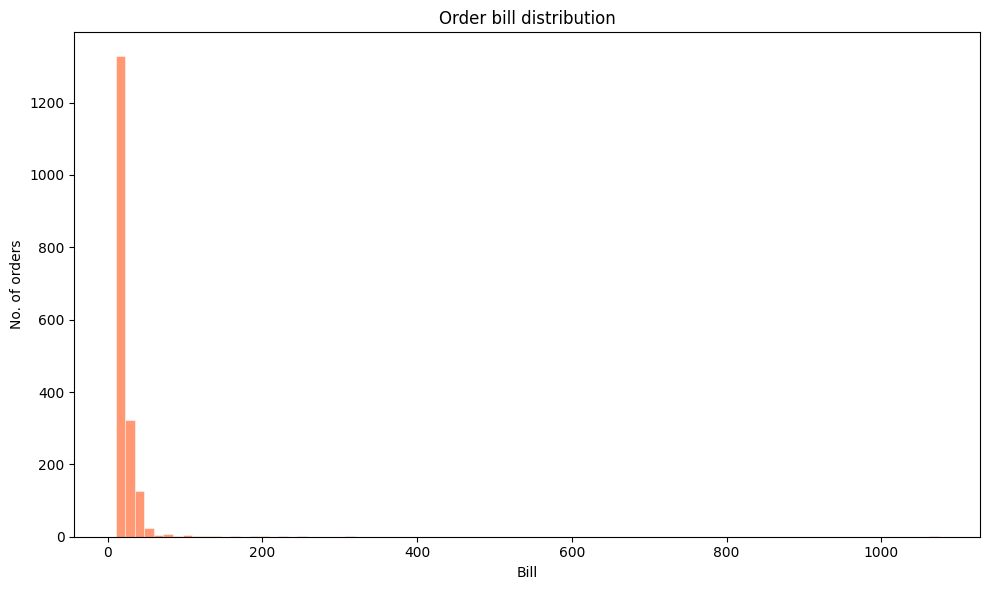

In [ ]:
#interpretation: total bill per order on the x-axis, and the histogram represents how many orders fall in each bill range 

chipo['total'] = chipo['quantity'] * chipo['item_price']
w = chipo.groupby('order_id')['total'].sum()

plt.figure(figsize = (10, 6))
plt.hist(w, 
         bins = 'auto',                    
         color = 'coral',
         edgecolor = 'white',
         linewidth = 0.4,
         alpha = 0.8)

plt.xlabel('Bill')
plt.ylabel('No. of orders')
plt.title('Order bill distribution')

plt.tight_layout()
plt.show()

#on taking bins < 100 (10, 20, 50), i found out that there weren't many bars in that; just one bar which was clearly visible (the tallest
#one in this histogram), while the others were almost invisible
#this was because the chipotle dataset is heavily concentrated on a smaller range of values, and thus, we need a higher value of bins if 
#we want to see the other bars 